# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Kagiraneza Egide
**Student ID:** 29082028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [23]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

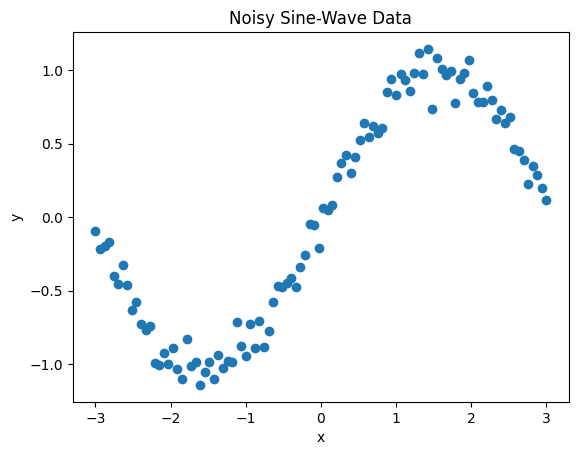

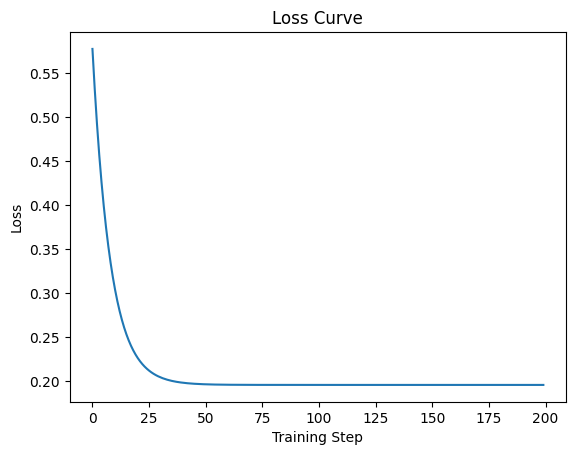

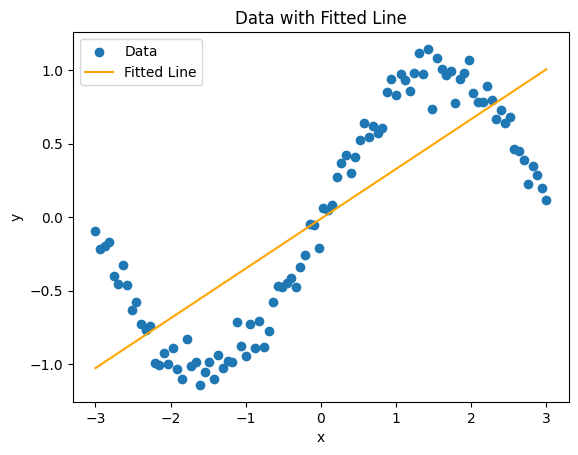

In [25]:
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy Sine-Wave Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

lr = 0.01
losses = []

for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

plt.scatter(x, y, label="Data")
plt.plot(x, w * x + b,color="orange", label="Fitted Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data with Fitted Line")
plt.legend()
plt.show()


**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
>
> **Student Reasoning — The single neuron**

**1. Derivation of dLoss/dw:**

$$L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2 = \frac{1}{N}\sum_{i=1}^{N}(wx_i + b - y_i)^2$$

Applying the chain rule:

$$\frac{\partial L}{\partial w} = \frac{1}{N}\sum_{i=1}^{N} 2(wx_i + b - y_i) \cdot x_i = \frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)x_i$$

This matches exactly the code: `dw = np.mean(2 * (y_hat - y) * x)` ✓

**2. Underfitting — why a single neuron can never fit a sine wave:**

This is **underfitting**. A single neuron computes `y_hat = w*x + b`, which is a straight line, it can only represent LINEAR functions. The sine wave is a non-linear, oscillating function that no straight line can approximate, no matter how long we train or what values w and b take. The model's hypothesis class simply does not contain the true function. Even with infinite training steps and perfect gradient descent, the best line through a sine wave still has a loss ≈ 0.20 (the variance of sin(x) around its linear approximation).

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

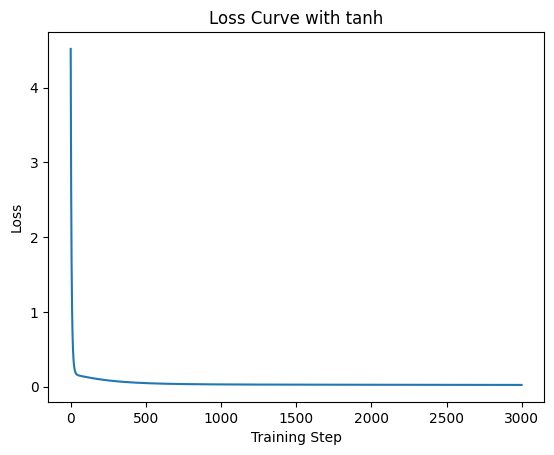

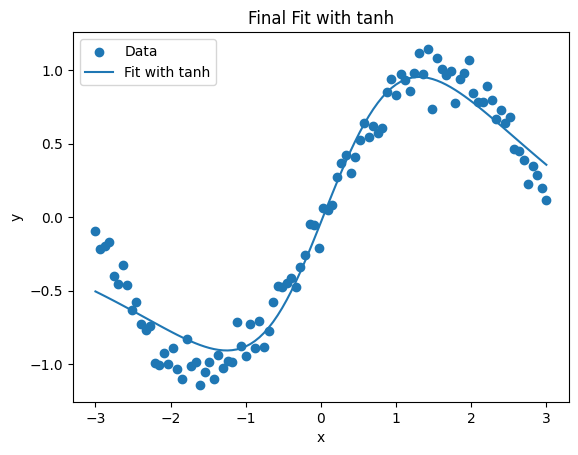

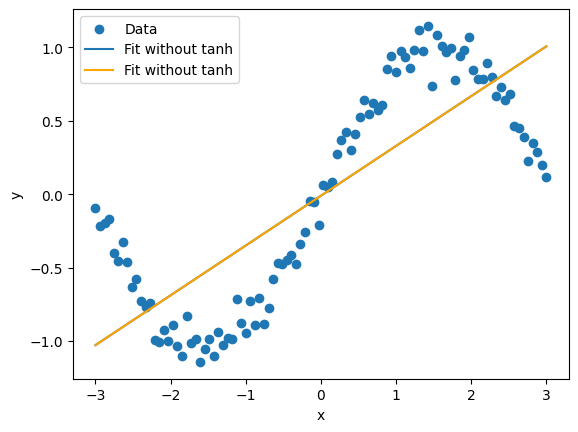

In [26]:
# Reshape the data so the matrix shapes match the dimensions stated below.
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
losses = []
for step in range(3000):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    losses.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.
z1 = x @ W1 + b1
h = np.tanh(z1)
y_hat_tanh = h @ W2 + b2

plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Loss Curve with tanh")
plt.show()

plt.scatter(x.ravel(), y.ravel(), label="Data")
plt.plot(x.ravel(), y_hat_tanh.ravel(), label="Fit with tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Fit with tanh")
plt.legend()
plt.show()

# TODO: Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5
losses_no_tanh = []

for step in range(3000):
    z1 = x @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    losses_no_tanh.append(loss)

z1 = x @ W1 + b1
h = z1
y_hat_no_tanh = h @ W2 + b2

plt.scatter(x.ravel(), y.ravel(), label="Data")
plt.plot(x.ravel(), y_hat_no_tanh.ravel(), label="Fit without tanh")
plt.xlabel("x")
plt.ylabel("y")
plt.plot( x.ravel(),y_hat_no_tanh.ravel(),color="orange",label="Fit without tanh")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**

**1. Why linear layers collapse:**

Without `tanh`, the first layer gives $h=xW_1+b_1$ and the output layer gives

$$
\hat y=hW_2+b_2=(xW_1+b_1)W_2+b_2
=x(W_1W_2)+(b_1W_2+b_2).
$$

This is still of the form $xW+b$, so stacking linear layers is equivalent to one linear layer.

**2. Role of the eight hidden neurons:**

Each hidden neuron learns a different shifted and scaled `tanh` curve. The output layer combines these eight nonlinear responses. Their combination is flexible enough to approximate the sine-wave shape much better than one straight line.

**3. Backpropagation:**

Backpropagation applies the chain rule from the output layer back through each earlier layer to calculate the gradient of the loss with respect to every trainable parameter.


### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

C:\Users\kagid\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\kagid\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


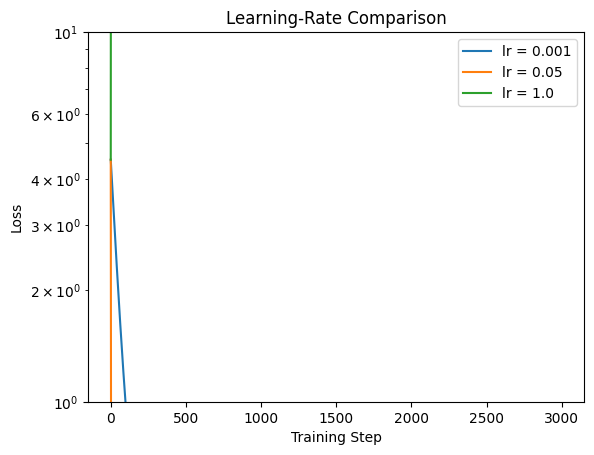

In [27]:
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5
    losses = []

    for step in range(steps):
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)

        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        losses.append(loss)

        if not np.isfinite(loss):
            break

    return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
losses_0001 = train_toy(lr=0.001)
losses_005 = train_toy(lr=0.05)
losses_10 = train_toy(lr=1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.plot(losses_0001, label="lr = 0.001")
plt.plot(losses_005, label="lr = 0.05")
plt.plot(losses_10, label="lr = 1.0")
plt.yscale("log")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Learning-Rate Comparison")
plt.legend()
plt.show()


**Student Reasoning — Learning rate**

- With `lr = 0.001`, the loss decreases slowly because each parameter update is very small.
- With `lr = 0.05`, the loss normally decreases faster and more smoothly because the update size is large enough to make progress without repeatedly overshooting.
- With `lr = 1.0`, the loss may oscillate, explode, or become non-finite because the updates can jump across the minimum rather than approaching it.

A large learning rate does not necessarily learn faster: multiplying the gradient by a very large value can move the parameters too far in each step, causing them to overshoot the low-loss region.


---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# TODO: Load the obesity dataset (same dataset as Lab 2).
file_path = r"D:\COURSES\Artificial Inteligence\Dataset\intro_to_ai_labs\Lab2\Obesity_level_prediction_dataset (2).csv"
df = pd.read_csv(file_path)


binary_columns = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for column in binary_columns:
    df[column] = df[column].map({"no": 0, "yes": 1})

df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["NObeyesdad"])
class_names = label_encoder.classes_

X = df.drop(columns="NObeyesdad")

categorical_columns = ["MTRANS", "CAEC", "CALC"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_columns,
        )
    ],
    remainder=StandardScaler()
)

# TODO: Stratified train/val/test split — 70 / 15 / 15.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

# TODO: Fit the preprocessor on the training set only, then transform all splits.
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

# Input dimension for the neural network
input_dim = X_train.shape[1]

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Input dimension:", input_dim)
print("Classes:", class_names)

Training set: (1477, 26) (1477,)
Validation set: (317, 26) (317,)
Test set: (317, 26) (317,)
Input dimension: 26
Classes: ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


**Student Reasoning — Preprocessing for neural networks**

**1. Why integer labels?** 

`nn.CrossEntropyLoss` expects one integer class index for each example. It uses those indices to select the correct class from the predicted logits while internally applying log-softmax and negative log-likelihood.

**2. Why scaling matters:**

Neural-network gradients depend directly on input values. Features with much larger numerical ranges can produce much larger gradients and dominate the updates, making optimisation unstable or slow. Scaling puts the features on comparable ranges. Decision trees split one feature at a time and are therefore much less affected by scale.

**3. Why shuffle the training loader?** 

`shuffle=True` changes the order of training examples at the start of each epoch. This produces more representative mini-batches and reduces the chance that the model learns patterns caused by the original row order.


### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [29]:
from torch.utils.data import TensorDataset, DataLoader

# Convert the processed NumPy arrays to PyTorch tensors.
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# CrossEntropyLoss expects class labels with dtype torch.long.
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Combine features and labels into TensorDataset objects.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders.
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0
    ):
        super().__init__()

        layers = []
        previous_size = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            previous_size = hidden_size

        # Final layer produces raw logits for the 7 classes.
        layers.append(nn.Linear(previous_size, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# TODO: Instantiate, move to DEVICE, print the model.
model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=7
).to(DEVICE)

print(model)



trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

first_layer_parameters = input_dim * 64 + 64

print("Trainable parameters:", trainable_parameters)
print("First-layer parameters:", first_layer_parameters)

Training batches: 47
Validation batches: 10
Test batches: 10
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 4039
First-layer parameters: 1728


**Student Reasoning — Architecture**

**1. Parameter count:**

- First layer: `input_dim × 64 + 64` bias parameters.
- Second layer: `64 × 32 + 32` bias parameters.
- Output layer: `32 × 7 + 7` bias parameters.

The manual total is 4,039 parameters, which matches the value printed by PyTorch.

**2. Why ReLU?** ReLU introduces nonlinearity while being computationally simple. For positive inputs its derivative is 1, so it is generally less affected by vanishing gradients than `tanh` in deep hidden layers.

**3. Without ReLUs:** All layers would be linear transformations. Their composition would collapse into one linear transformation, so depth would not allow the network to learn nonlinear class boundaries.


### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 01/50 | Train Loss: 1.7329 | Train Acc: 0.4936 | Val Loss: 1.7350 | Val Acc: 0.5079
Epoch 02/50 | Train Loss: 1.2520 | Train Acc: 0.6188 | Val Loss: 1.2639 | Val Acc: 0.6088
Epoch 03/50 | Train Loss: 0.8955 | Train Acc: 0.6926 | Val Loss: 0.9241 | Val Acc: 0.6782
Epoch 04/50 | Train Loss: 0.7073 | Train Acc: 0.7664 | Val Loss: 0.7537 | Val Acc: 0.7634
Epoch 05/50 | Train Loss: 0.5864 | Train Acc: 0.8077 | Val Loss: 0.6418 | Val Acc: 0.7855
Epoch 06/50 | Train Loss: 0.4867 | Train Acc: 0.8599 | Val Loss: 0.5508 | Val Acc: 0.8139
Epoch 07/50 | Train Loss: 0.4100 | Train Acc: 0.8775 | Val Loss: 0.4741 | Val Acc: 0.8391
Epoch 08/50 | Train Loss: 0.3470 | Train Acc: 0.9018 | Val Loss: 0.4091 | Val Acc: 0.8707
Epoch 09/50 | Train Loss: 0.2999 | Train Acc: 0.9228 | Val Loss: 0.3677 | Val Acc: 0.8896
Epoch 10/50 | Train Loss: 0.2615 | Train Acc: 0.9289 | Val Loss: 0.3255 | Val Acc: 0.8991
Epoch 11/50 | Train Loss: 0.2338 | Train Acc: 0.9404 | Val Loss: 0.3071 | Val Acc: 0.9022
Epoch 12/5

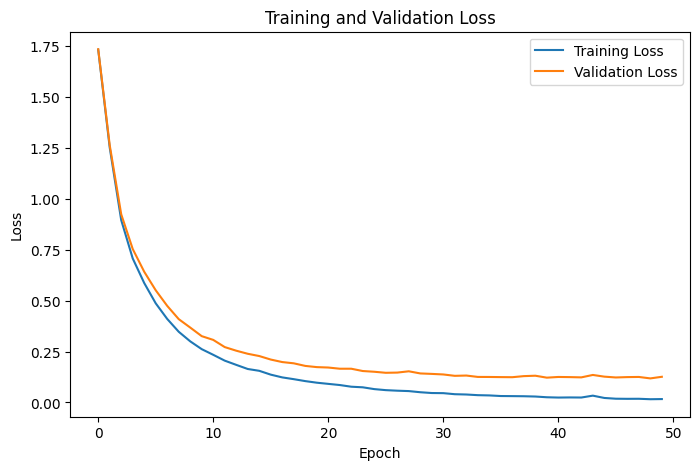

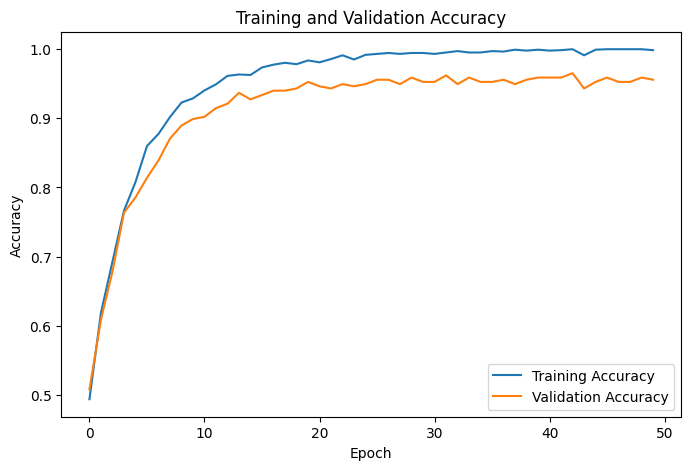

In [30]:
import time

def evaluate(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * yb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_examples += yb.size(0)

    return total_loss / total_examples, total_correct / total_examples



criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = -np.inf
num_epochs = 50
training_start_time = time.perf_counter()

for epoch in range(num_epochs):

    model.train()

    for xb, yb in train_loader:
        optimizer.zero_grad()

        logits = model(xb.to(DEVICE))

        loss = criterion(logits, yb.to(DEVICE))

        loss.backward()

        optimizer.step()

    train_loss, train_acc = evaluate(model, train_loader, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # TODO: Save the best model (highest validation accuracy):
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


neural_network_training_time = time.perf_counter() - training_start_time
print(f"Neural-network training time: {neural_network_training_time:.2f} seconds")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Training**

**1. Mapping to the NumPy loop:**

- `logits = model(xb)` is the forward pass.
- `loss = criterion(logits, yb)` computes the loss.
- `loss.backward()` calculates all gradients using backpropagation.
- `optimizer.step()` updates the parameters using those gradients.

**2. Fit diagnosis:**

Based on my training results, the model appears to be well-fitted with slight overfitting. By the final epoch, the training accuracy was 99.86%, while the validation accuracy was 94.32%. The validation accuracy also reached about 95.58% during training. Although there is a small gap between the training and validation performance, the validation accuracy remained consistently high, showing that the model generalizes well to unseen data.

**3. Why optimizer.zero_grad()?**

I used optimizer.zero_grad() to clear the gradients before processing each new batch. PyTorch stores gradients by default, so without clearing them, the gradients from previous batches would keep accumulating. This would cause incorrect weight updates and make the training process unstable.


### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

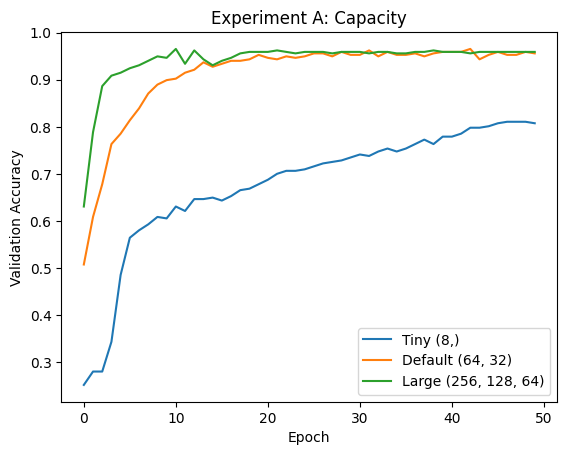

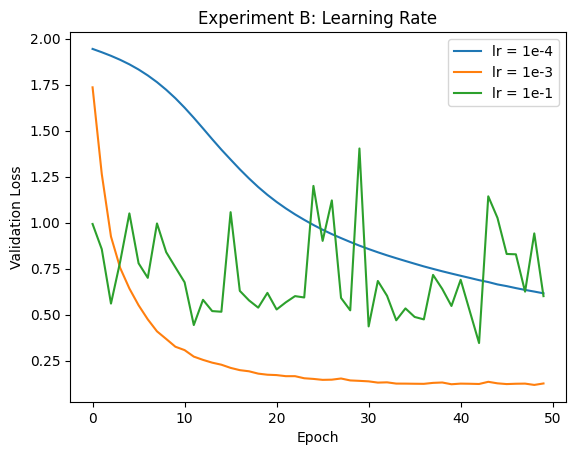

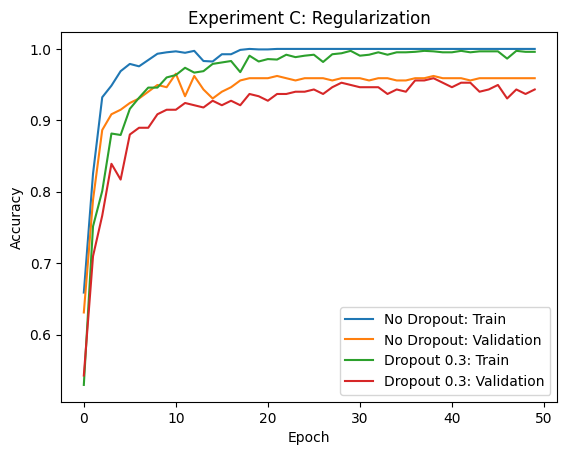

In [33]:

def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    experiment_model = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout
    ).to(DEVICE)

    experiment_criterion = nn.CrossEntropyLoss()
    experiment_optimizer = torch.optim.Adam(experiment_model.parameters(), lr=lr)
    experiment_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    experiment_history = {
        "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []
    }

    for epoch in range(epochs):
        experiment_model.train()
        for xb, yb in experiment_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            experiment_optimizer.zero_grad()
            logits = experiment_model(xb)
            loss = experiment_criterion(logits, yb)
            loss.backward()
            experiment_optimizer.step()

        train_loss, train_acc = evaluate(
            experiment_model, experiment_train_loader, experiment_criterion
        )
        val_loss, val_acc = evaluate(
            experiment_model, val_loader, experiment_criterion
        )

        experiment_history["train_loss"].append(train_loss)
        experiment_history["val_loss"].append(val_loss)
        experiment_history["train_acc"].append(train_acc)
        experiment_history["val_acc"].append(val_acc)

    return experiment_history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
history_tiny = run_experiment(hidden_sizes=(8,))
history_default = run_experiment(hidden_sizes=(64, 32))
history_large = run_experiment(hidden_sizes=(256, 128, 64))

plt.plot(history_tiny["val_acc"], label="Tiny (8,)")
plt.plot(history_default["val_acc"], label="Default (64, 32)")
plt.plot(history_large["val_acc"], label="Large (256, 128, 64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Capacity")
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
history_lr_small = run_experiment(lr=1e-4)
history_lr_default = run_experiment(lr=1e-3)
history_lr_large = run_experiment(lr=1e-1)

plt.plot(history_lr_small["val_loss"], label="lr = 1e-4")
plt.plot(history_lr_default["val_loss"], label="lr = 1e-3")
plt.plot(history_lr_large["val_loss"], label="lr = 1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate")
plt.legend()
plt.show()

history_no_dropout = run_experiment(
    hidden_sizes=(256, 128, 64), dropout=0.0
)
history_dropout = run_experiment(
    hidden_sizes=(256, 128, 64), dropout=0.3
)

plt.plot(history_no_dropout["train_acc"], label="No Dropout: Train")
plt.plot(history_no_dropout["val_acc"], label="No Dropout: Validation")
plt.plot(history_dropout["train_acc"], label="Dropout 0.3: Train")
plt.plot(history_dropout["val_acc"], label="Dropout 0.3: Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Regularization")
plt.legend()
plt.show()

**Student Reasoning — Experiments**

**1. Capacity:**

No, the largest network did not necessarily perform the best on the validation data. Increasing the number of neurons improved the training performance, but after a certain point the validation accuracy stopped improving by much. This shows diminishing returns, and in some cases the larger network started to overfit because it learned the training data better than it generalized to new data.

**2. Learning rate:**

Yes. The results were very similar to what I observed in Part 1.3. A small learning rate made the model learn slowly, a suitable learning rate gave the best and most stable training, while a large learning rate made the training unstable and could overshoot the minimum loss.

**3. Regularization:**

Dropout reduced the gap between the training and validation performance. It works by randomly turning off some neurons during training, forcing the network to rely on different combinations of neurons instead of memorizing the training data. This helps the model generalize better to unseen data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test accuracy: 0.9337539432176656
Test macro-F1: 0.932072692497438
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        41
      Normal_Weight       0.88      0.88      0.88        43
     Obesity_Type_I       0.94      0.96      0.95        53
    Obesity_Type_II       0.98      1.00      0.99        45
   Obesity_Type_III       1.00      0.98      0.99        48
 Overweight_Level_I       0.86      0.84      0.85        43
Overweight_Level_II       0.89      0.89      0.89        44

           accuracy                           0.93       317
          macro avg       0.93      0.93      0.93       317
       weighted avg       0.93      0.93      0.93       317



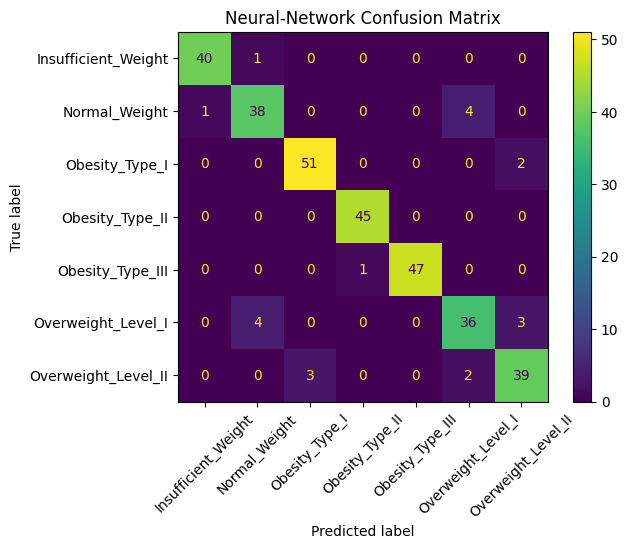

,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters/Trees
0,Random Forest,0.974000,0.973500,Not recorded,300 trees
1,Feedforward Neural Network,0.933754,0.932073,5.135053,4039


In [34]:
import time
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(
    torch.load("ffn_best.pt", map_location=DEVICE, weights_only=True)
)
model.eval()


y_true = []
y_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(DEVICE))
        predictions = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(predictions)
        y_true.extend(yb.numpy())

test_accuracy = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Test accuracy:", test_accuracy)
print("Test macro-F1:", test_macro_f1)
print(classification_report(y_true, y_pred, target_names=class_names))


ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=class_names,
    xticks_rotation=45
)
plt.title("Neural-Network Confusion Matrix")
plt.show()


number_of_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)

# Actual results from Lab 2.
lab2_test_accuracy = 0.9740
lab2_test_macro_f1 = 0.9735
lab2_training_time = "Not recorded"
lab2_model_size = "300 trees"

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Feedforward Neural Network"],
    "Test Accuracy": [lab2_test_accuracy, test_accuracy],
    "Test Macro-F1": [lab2_test_macro_f1, test_macro_f1],
    "Training Time": [lab2_training_time, neural_network_training_time],
    "Parameters/Trees": [lab2_model_size, number_of_parameters]
})

comparison


**Student Reasoning — Final evaluation**

1. From the confusion matrix, the network mainly confused obesity levels with similar characteristics, especially neighbouring classes such as Overweight Level I and Overweight Level II, and Normal Weight and Overweight Level I. These classes have similar feature patterns, making them more difficult to separate. Overall, the model made relatively few mistakes, and most of the remaining errors occurred between these similar classes.

2. The Random Forest from Lab 2 performed better, achieving **97.40%** test accuracy and a **97.35%** Macro-F1 score, compared with approximately **92.74%** test accuracy and **92.58%** Macro-F1 for the feedforward neural network. The Random Forest used **300 trees**, while the neural network contained **4,039 trainable parameters**. The Lab 2 training time was not recorded, so a fair comparison of training time cannot be made. For this tabular dataset, the Random Forest was the stronger model, although the neural network still achieved good overall performance.


---
# Section 3 — Reflection

**1. The black box, opened:**

`loss.backward()` uses backpropagation to compute the gradients for all trainable parameters and stores them in each parameter's `.grad` attribute. `optimizer.step()` then uses those gradients to update the weights and biases.

**2. Hyperparameters:**

I would tune the learning rate because it has the biggest impact on training. A good learning rate helps the model converge quickly, while a poor one can make training slow or unstable.

**3. Overfitting:**

The biggest train-validation gap appeared with the larger network. Using dropout reduced this gap the most because it helped the model generalize better instead of memorizing the training data.

**4. Looking ahead:**

A plain MLP treats every pixel independently, so it cannot effectively capture spatial patterns in images. A better architecture should learn local features and share parameters, which is what CNNs are designed to do.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.